# Finding pilot patient

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from results_functions import extract_ews, extract_tws, grand_average, plot_all_patients, get_scores_all_patients
from db import patients_db


In [3]:
# Combine ews for all patients
# pickle_name = "performances_v1"
# strategy = "transfer"
pickle_name = "performances_static_v1"
strategy = "static"
clf = "btlda"
score = "ews"

ews_all_static = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False)
ews_avg_static = grand_average(ews_all_static) 

FileNotFoundError: [Errno 2] No such file or directory: 'p2_performances_static_v1.pkl'

In [2]:
pickle_name = "window_v3"
strategy = "window_v3"
clf = "btlda"
score = "ews"

ews_all_window_v3 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False)
ews_avg_window_v3 = grand_average(ews_all_window_v3)

In [32]:
pickle_name = "window_v4"
strategy = "window_v4"
clf = "btlda"
score = "ews"

ews_all_window_v4 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False)
ews_avg_window_v4 = grand_average(ews_all_window_v4) 

In [33]:
# Fixed window 3600
pickle_name = "window_v5"
strategy = "window_v5"
clf = "btlda"
score = "ews"

ews_all_window_v5 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False)
ews_avg_window_v5 = grand_average(ews_all_window_v5) 

In [4]:
with open('p2_cc_v1.pkl', 'rb') as f:
    p1_performances_v1 = pickle.load(f) 

print(p1_performances_v1.keys())
#print(p1_performances_v1.get('p1_transfer_s3_v2'))

with open('p2_cc_v2.pkl', 'rb') as f:
    p1_performances_v2 = pickle.load(f) 

print(p1_performances_v2.keys())
#print(p1_performances_v1.get('p1_transfer_s3_v2'))

dict_keys(['p2_cc_1_s3', 'p2_cc_1_s4', 'p2_cc_1_s5', 'p2_cc_1_s6', 'p2_cc_1_s7', 'p2_cc_1_s8', 'p2_cc_1_s9', 'p2_cc_1_s10', 'p2_cc_1_s11', 'p2_cc_1_s12', 'p2_cc_1_s13'])
dict_keys(['p2_cc_v2_s3', 'p2_cc_v2_s4', 'p2_cc_v2_s5', 'p2_cc_v2_s6', 'p2_cc_v2_s7', 'p2_cc_v2_s8', 'p2_cc_v2_s9', 'p2_cc_v2_s10', 'p2_cc_v2_s11', 'p2_cc_v2_s12', 'p2_cc_v2_s13'])


In [38]:
import pandas as pd
def _create_dataframe(dict):
    df_long = pd.DataFrame(dict)
    return df_long

def extract_ews_v3(performances, patient_nr: int, last_online_session: int, strategy="", verbose=False, version_suffix=""):
    if verbose:
        print(f"Extracting from performances with the following keys: \n{performances.keys()}")
        print(f"strategy: {strategy}")

    #ews_transfer_lda = np.zeros(last_online_session-2)
    

    session = 3 # first online session
    p = patient_nr
    extra = 0

    if p == 8:
        session = 4
        extra +=1
    
    ews_btlda = np.zeros(last_online_session-2-extra)

    for i in range(last_online_session-2-extra):
        ews_btlda[i] = performances.get(f'p{p}_{strategy}_s{session}{version_suffix}').get('epoch-wise').get('btlda')
        session+=1
    return ( 
        ews_btlda)  

test = _create_dataframe(ews_all_window_v4)
print(test)
test.to_csv(f"testttt.csv")

ValueError: All arrays must be of the same length

In [5]:
pickle_name = "transfer_v2"
strategy = "transfer"
clf = "btlda"
score = "ews"

ews_all_transfer = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, version_suffix="_v2")
ews_avg_transfer = grand_average(ews_all_transfer) 


In [15]:
pickle_name = "cc_v1"
strategy = "cc_1"
clf = "btlda"
score = "ews"

ews_all_cc_v1 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False)
ews_avg_cc_v1 = grand_average(ews_all_cc_v1) 


In [16]:
pickle_name = "cc_v2"
strategy = "cc_v2"
clf = "btlda"
score = "ews"

ews_all_cc_v2 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False)
ews_avg_cc_v2 = grand_average(ews_all_cc_v2) 


In [8]:
from results_functions import extract_ews_transfer_v2, extract_tws_transfer_v2
def get_scores_all_patients_transfer_v2(pickle_suffix="", strategy="", classifier="", score=None, verbose=False):
    """
    Collects epoch-wise accuracy scores for all sessions, for every patient. Stores all scores together in a dictionary.

    Parameters:
    - pickle_suffix: e.g. "performances_v1"
    - strategy: e.g. "transfer" or "static" etc.
    - classifier: "btlda" or "slda"
    - verbose: True for printing the process, False otherwise
    
    Output:
    - ews_clf_all_combined (dict):{
                                    "p1": [score1, score2, ...],
                                    "p2": [score1, score2, ...],
                                    ...
                                    "p10": [score1, score2, ...]
                                    }

    Example usage:
    > # Collecting ews scores of Transfer Fixed BT-LDA
    > strategy = "transfer"
    > clf = "btlda"
    > pickle_name = "performances_v1"
    > ews_btlda_all_results = ews_all_patients(pickle_name, strategy, clf, verbose=False)                                
    """
    
    # To do: add check for right strategy values (& check for pickle suffix)

    assert classifier in ["btlda", "slda"], "Given classifier is not recognized. Accepts only btlda or slda"
    if classifier == "btlda":
        clf_index = 1
    elif classifier == "slda":
        clf_index = 0    

    assert score in ["ews", "tws"], "Invalid score given. The following scores are valid input: ['ews', 'tws']"

    # Combine ews for all patients
    scores_all_patients = dict()

    for id in patients_db:

        info = patients_db.get(id)
        patient = info.get('patient_nr')
        last_session = info.get('last_session')
        calibration_selection = info.get('selection')

        if verbose:
            print("patient: ", patient)
            print("last session", last_session)
            print("calibration_selection", calibration_selection)

        with open(f'p{patient}_{pickle_suffix}.pkl', 'rb') as f:
            performances_new = pickle.load(f)    

        if score=="ews":   
            scores_transfer_btlda = extract_ews_transfer_v2(performances_new, patient, last_session-1, strategy, verbose=verbose) 
            # scores_transfer_slda, scores_transfer_btlda = extract_ews(performances_new, patient, last_session-1, strategy, verbose=verbose)
        #tws_transfer_slda_08_06, tws_transfer_btlda_08_06 = extract_tws_transfer_08_06(performances_new, patient, last_session-1)
        elif score=="tws":
            scores_transfer_btlda = extract_tws_transfer_v2(performances_new, patient, last_session-1, strategy, verbose)
            # scores_transfer_slda, scores_transfer_btlda = extract_tws(performances_new, patient, last_session-1, strategy, verbose)

        scores_all_patients.update({f"p{patient}": (scores_transfer_btlda)})

    return scores_all_patients


In [9]:
pickle_name = "transfer_v2"
strategy = "transfer"
clf = "btlda"
score = "ews"

ews_all_transfer_v2 = get_scores_all_patients_transfer_v2(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False)
ews_avg_transfer_v2 = grand_average(ews_all_transfer_v2) 

In [28]:
t1_scores = []
for p in ews_all_transfer.keys():
    t1_scores.append(ews_all_transfer.get(p))

# w3_scores = []
# for p in ews_all_window_v3.keys():
#     w3_scores.append(ews_all_window_v3.get(p))    

print(len(t1_scores)) 
print((t1_scores[8]))   
print(t1_scores[1])
print(np.concatenate(t1_scores)[15:20])

t2_scores = []
for p in ews_all_transfer_v2.keys():
    t2_scores.append(ews_all_transfer_v2.get(p))

w4_scores = []
for p in ews_all_window_v4.keys():
    w4_scores.append(ews_all_window_v4.get(p))  

w5_scores = []
for p in ews_all_window_v5.keys():
    w5_scores.append(ews_all_window_v5.get(p))     

import pandas as pd
data = []
for patient, patient_scores in enumerate(t1_scores, start=1):
    for session_id, score in enumerate(patient_scores, start=3):
        if patient==8 and session_id==3: # skip session 18 for  p8 bc that has value 0 (p8 started one session later than the rest)
            continue
        else:
            data.append(({'patient': patient, 'session': session_id, 'ews': score}))
df = pd.DataFrame(data)
print(df)
df.to_csv('transferdata.csv', index=False)


10
[0.59916236 0.76489744 0.74928002 0.62612545 0.81168803 0.76517108
 0.65014197 0.81944923 0.51872726 0.52858162 0.5064112  0.50638812
 0.57668894 0.56389389 0.57015256]
[0.61796566 0.65243459 0.62695915 0.63800903 0.6580305  0.64743165
 0.62568775 0.55889632 0.58183914 0.66929099 0.69038195]
[0.61796566 0.65243459 0.62695915 0.63800903 0.6580305 ]
     patient  session       ews
0          1        3  0.595737
1          1        4  0.707443
2          1        5  0.730597
3          1        6  0.745014
4          1        7  0.825825
..       ...      ...       ...
144       10       11  0.612618
145       10       12  0.580743
146       10       13  0.607255
147       10       14  0.539391
148       10       15  0.596690

[149 rows x 3 columns]


In [12]:
from scipy.stats import wilcoxon
import numpy as np
# before = ews_all_transfer
# after = ews_all_window_v3
before = np.concatenate(t2_scores)
after = np.concatenate(w4_scores)
W_statistic_s, p_value_s = wilcoxon(before, after)
if p_value_s < 0.05:
   print("There is a statistically significant difference.")
else:
    print("There is no statistically significant difference.")
print(f"W-statistic: {W_statistic_s}, p-value: {p_value_s}")


There is a statistically significant difference.
W-statistic: 1864.0, p-value: 1.708828905001704e-12


In [29]:
from scipy.stats import wilcoxon
import numpy as np

t1_ews_scores = []
for p in ews_all_transfer.keys():
    t1_ews_scores.append(ews_all_transfer.get(p))

# w3_scores = []
# for p in ews_all_window_v3.keys():
#     w3_scores.append(ews_all_window_v3.get(p))    

# print(len(t1_scores)) 
# print((t1_scores[8]))   
# print(t1_scores[1])
# print(np.concatenate(t1_scores)[15:20])

t2_ews_scores = []
for p in ews_all_transfer_v2.keys():
    t2_ews_scores.append(ews_all_transfer_v2.get(p))

w4_ews_scores = []
for p in ews_all_window_v4.keys():
    w4_ews_scores.append(ews_all_window_v4.get(p))  

w5_ews_scores = []
for p in ews_all_window_v4.keys():
    w5_ews_scores.append(ews_all_window_v5.get(p))  

cc1_ews_scores = []
for p in ews_all_cc_v1.keys():
    cc1_ews_scores.append(ews_all_cc_v1.get(p)) 


cc2_ews_scores = []
for p in ews_all_cc_v2.keys():
    cc2_ews_scores.append(ews_all_cc_v2.get(p)) 

# before = ews_all_transfer_v2
# after = ews_all_window_v4
before = np.concatenate(t2_ews_scores)
after = np.concatenate(w4_ews_scores)
W_statistic_l, p_value_l = wilcoxon(before, after)
# if p_value_l < 0.05:
#    print("There is a statistically significant difference.")
# else:
#     print("There is no statistically significant difference.")
print(f"EWS w4 vs t2 - W-statistic: {W_statistic_l}, p-value: {p_value_l}")
w4_ews_scores_array = np.array([x for w in w4_ews_scores for x in w])
t2_ews_scores_array = np.array([x for w in t2_ews_scores for x in w])
print((t2_ews_scores_array[t2_ews_scores_array!=0] - w4_ews_scores_array[w4_ews_scores_array!=0]).mean())



before = np.concatenate(t2_ews_scores)
after = np.concatenate(w5_ews_scores)
W_statistic_l, p_value_l = wilcoxon(before, after)
print(f"EWS w4 vs t2: W-statistic: {W_statistic_l}, p-value: {p_value_l}")
t2_ews_scores_array = np.array([x for w in t2_scores for x in w])
w5_ews_scores_array = np.array([x for w in w5_scores for x in w])
print((t2_ews_scores_array[t2_ews_scores_array!=0] - w5_ews_scores_array[w5_ews_scores_array!=0]).mean())



before = np.concatenate(t2_ews_scores)
after = np.concatenate(cc1_ews_scores)
W_statistic_l, p_value_l = wilcoxon(before, after)
# if p_value_l < 0.05:
#    print("There is a statistically significant difference.")
# else:
#     print("There is no statistically significant difference.")
print(f"W-statistic: {W_statistic_l}, p-value: {p_value_l}")


before = np.concatenate(t2_ews_scores)
after = np.concatenate(cc2_ews_scores)
W_statistic_l, p_value_l = wilcoxon(before, after)
# if p_value_l < 0.05:
#    print("There is a statistically significant difference.")
# else:
#     print("There is no statistically significant difference.")
print(f"W-statistic: {W_statistic_l}, p-value: {p_value_l}")

cc2_ews_scores_array = np.array([x for w in cc2_ews_scores for x in w])
print((t2_ews_scores_array[t2_ews_scores_array!=0] - cc2_ews_scores_array[cc2_ews_scores_array!=0]).mean())

EWS w4 vs t2 - W-statistic: 1864.0, p-value: 1.708828905001704e-12
-0.01733901674566317
EWS w4 vs t2: W-statistic: 3478.0, p-value: 6.395946942348016e-05
-0.014248133763645634
W-statistic: 4749.0, p-value: 0.11205177506521809
W-statistic: 4845.0, p-value: 0.1593950888766701
-0.0010938018821389233


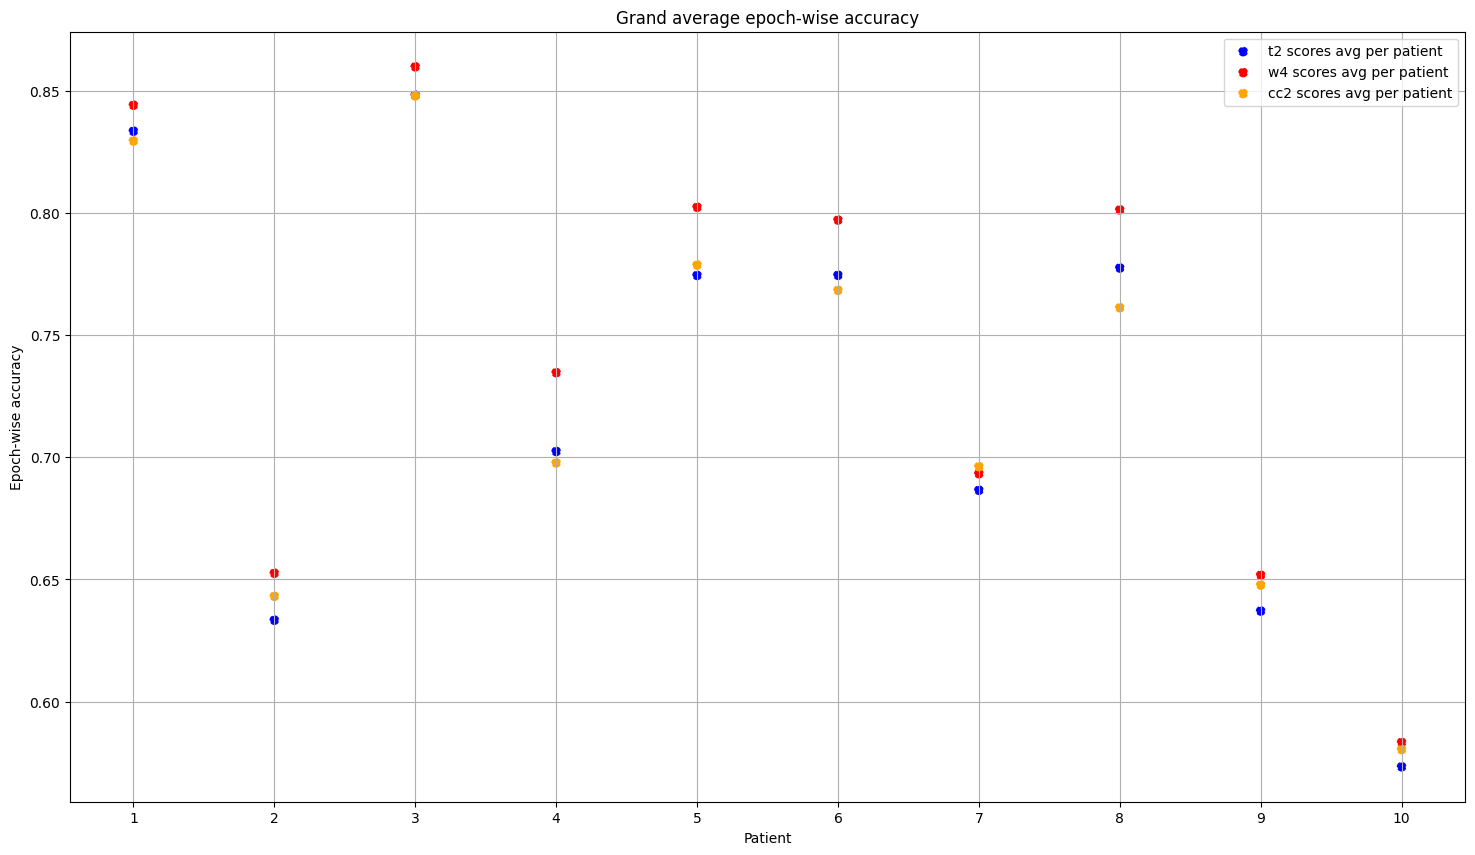

In [ ]:

plt.figure(figsize=(18,10))
#plt.plot(ews_avg_static, label="Static Fixed", linestyle='dashed')
# plt.plot([np.mean(l) for l in t1_scores],label="t1 scores", color="green")
# plt.plot([np.mean(l) for l in w3_scores],label="w3 scores", color="pink")

plt.scatter(y=[np.mean(l) for l in t2_ews_scores], x=np.arange(0,10),label="t2 scores avg per patient", color="blue", linestyle="dashed")
plt.scatter(y=[np.mean(l) for l in w4_ews_scores],x=np.arange(0,10), label="w4 scores avg per patient", color="red", linestyle="dashed")
plt.scatter(y=[np.mean(l) for l in cc2_ews_scores],x=np.arange(0,10), label="cc2 scores avg per patient", color="orange", linestyle="dashed")

# plt.plot(ews_avg_transfer, label="Transfer Fixed-V1 (s)", color="tab:blue")
# plt.plot(ews_avg_window_v3, label="Window v3 (s)", color="red")

# plt.plot(ews_avg_transfer_v2, label="Transfer Fixed V2 (l) avg per session", color="tab:blue",linestyle='dashed')
# plt.plot(ews_avg_window_v4, label="Window v4 (l) avg per session", color="red",linestyle='dashed')
plt.ylabel("Epoch-wise accuracy")
plt.xlabel('Patient')
#plt.ylim(0.1,1)
# plt.xticks(np.arange(0,25), np.arange(3,28))  
plt.xticks(np.arange(0,10), np.arange(1,11))  
plt.legend()    
plt.title("Grand average epoch-wise accuracy")   
plt.grid() 
plt.show()

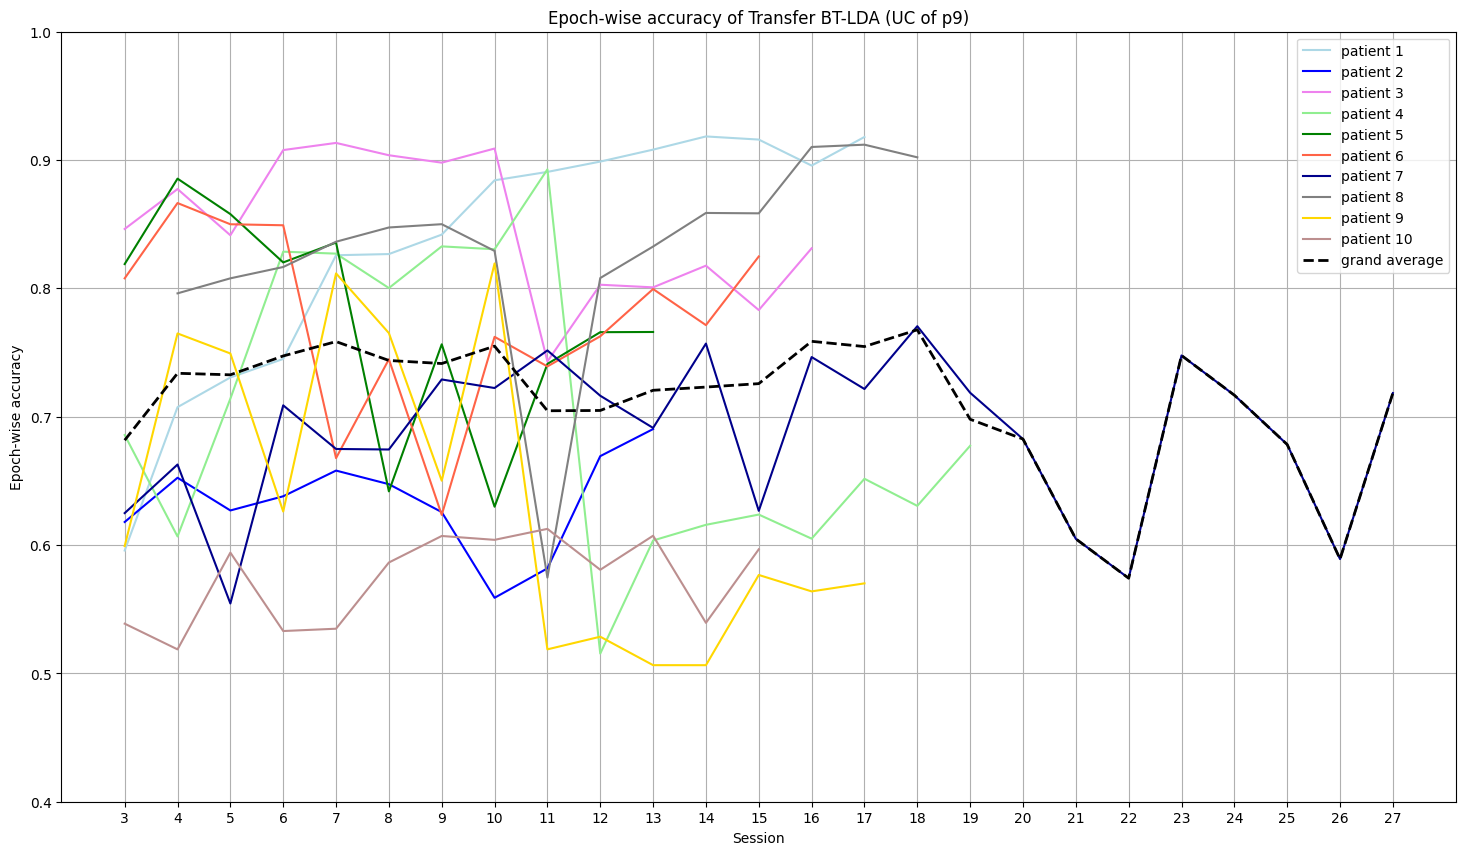

In [20]:

plot_all_patients(ews_all_transfer_v2, grand_avg=ews_avg_transfer_v2, title="Epoch-wise accuracy of Transfer BT-LDA (UC of p9)", ylabel="Epoch-wise accuracy")

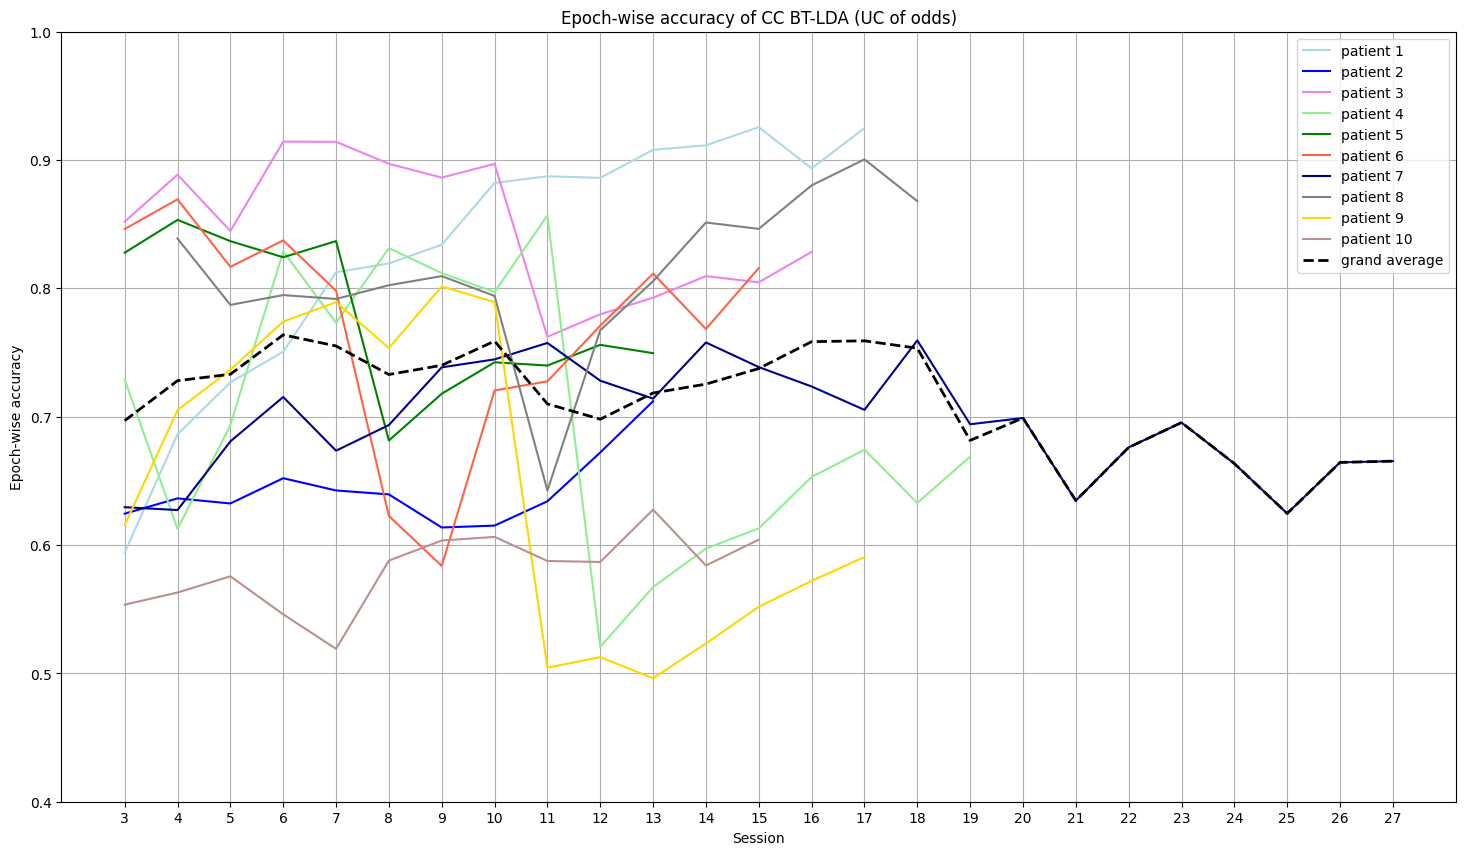

In [21]:
plot_all_patients(ews_all_cc_v2, grand_avg=ews_avg_cc_v2, title="Epoch-wise accuracy of CC BT-LDA (UC of odds)", ylabel="Epoch-wise accuracy")

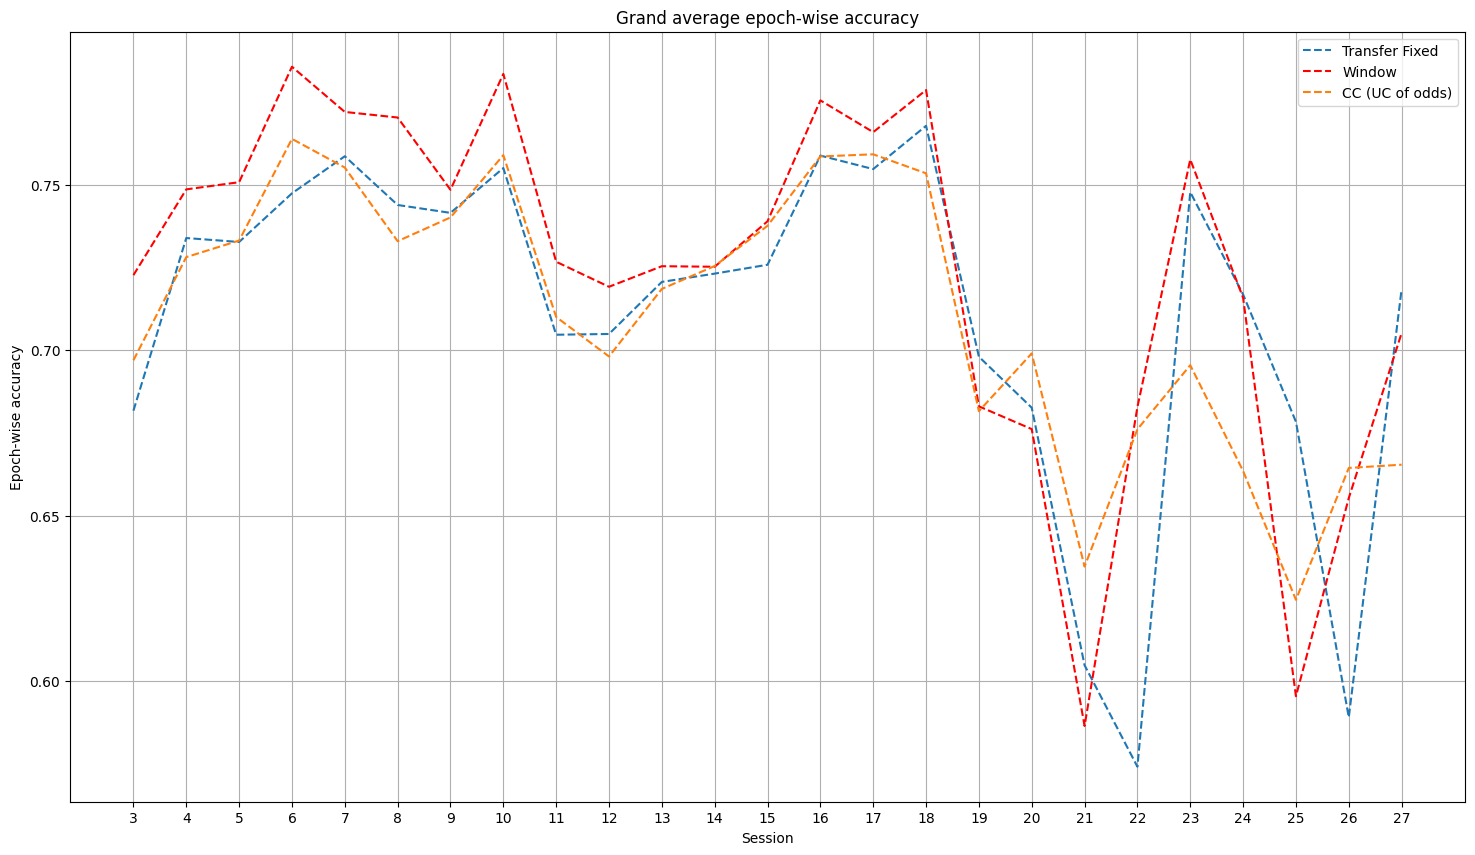

In [30]:
# plt.figure(figsize=(18,10))
# plt.plot(ews_avg_static, label="Static Fixed", linestyle='dashed')
# plt.plot(ews_avg_transfer, label="Transfer Fixed", linestyle='dashed')
# plt.ylabel("Epoch-wise accuracy")
# plt.xlabel('Session')
# plt.ylim(0.1,1)
# plt.xticks(np.arange(0,25), np.arange(3,28))    
# plt.legend()    
# plt.title("Grand average epoch-wise accuracy")   
# plt.grid() 
# plt.show()

plt.figure(figsize=(18,10))
plt.plot(ews_avg_transfer_v2, label="Transfer Fixed", linestyle='dashed')
plt.plot(ews_avg_window_v4, label="Window", linestyle='dashed', color="red")
#plt.plot(ews_avg_cc_v1, label="CC (UC of p9)", linestyle='dashed')
plt.plot(ews_avg_cc_v2, label="CC (UC of odds)", linestyle='dashed')

plt.ylabel("Epoch-wise accuracy")
plt.xlabel('Session')
#plt.ylim(0.1,1)
plt.xticks(np.arange(0,25), np.arange(3,28))    
plt.legend()    
plt.title("Grand average epoch-wise accuracy")   
plt.grid() 
plt.show()

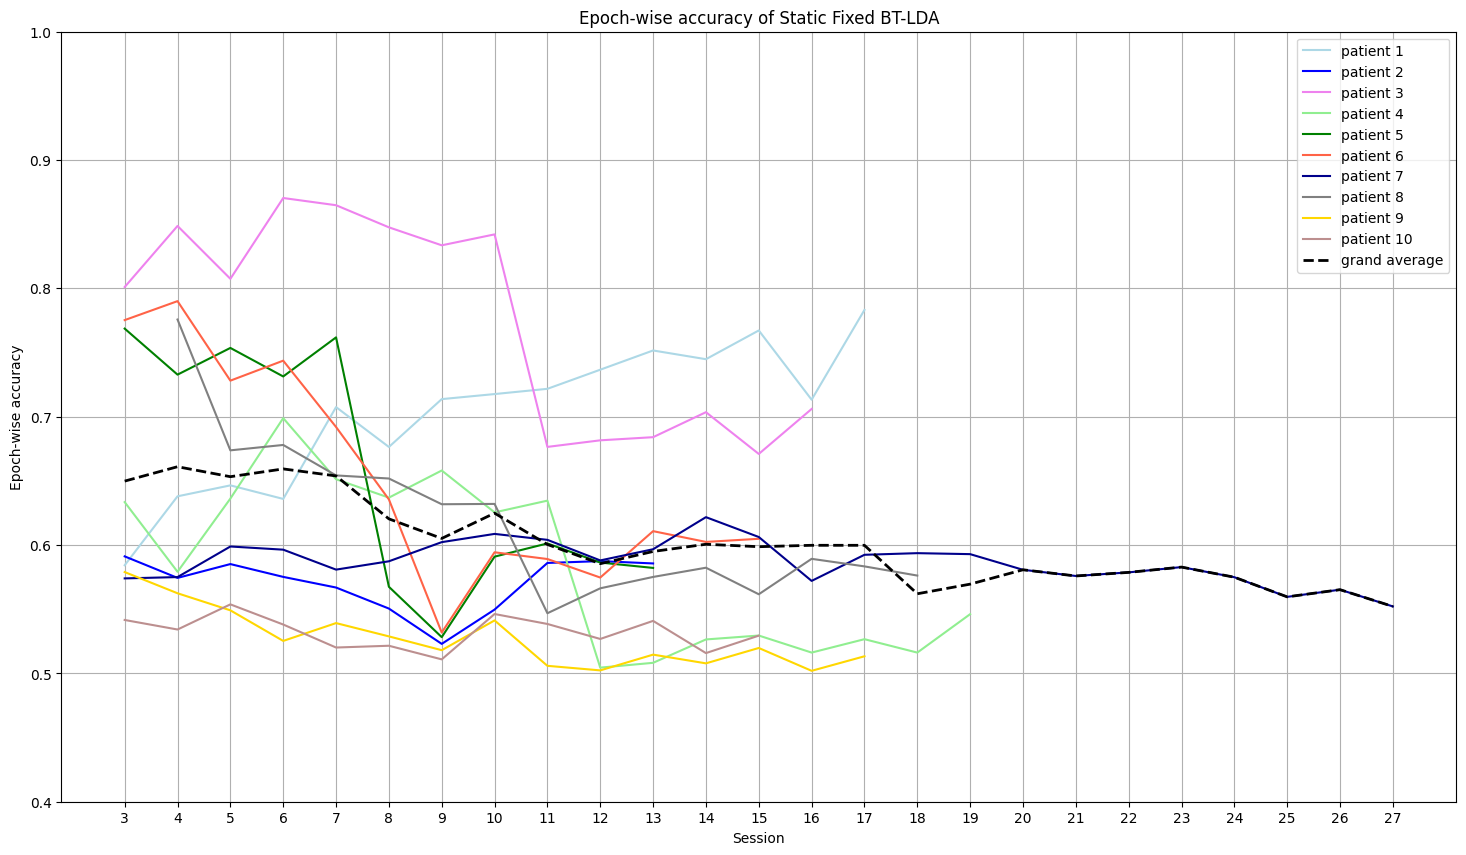

In [5]:

plot_all_patients(ews_all_static, grand_avg=ews_avg_static, title="Epoch-wise accuracy of Static Fixed BT-LDA", ylabel="Epoch-wise accuracy")

## tws